In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [2]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            # print(self.x_precion.format(self.x_scale[-1]))
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    joined= None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False, joined= False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.joined = joined
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=7
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = (xw+0.5)//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = (yw+0.5)//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1 or j==-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        try:
            current_ax.set_xlim(*self.xlim)
        except:
            pass
        try:
            current_ax.set_ylim(*self.ylim)
        except:
            pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.joined:
            
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            elif pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            elif pos=='outer_right':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
                current_ax.yaxis.set_label_position("right")
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
            
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

In [3]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    # sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    return np.array(sorted_comb)

In [4]:





def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    if Del_R==0:
        return 0
    elif interaction_radius and Del_R > interaction_radius + 0.01:
        return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



In [5]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(16)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # out = np.zeros([*mat_range,*shape],dtype=object)
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,j,base):
    # j = i%2
    # i= i//2
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

parallel_for([[0,2],[-1,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_argfunc_argfunc_argfunc_argfunc_arg    0 1 00 1 1 1 0  -1 0 1-1 0  00 
00

0




array([[[np.int16(0), np.int16(-1)],
        [np.int16(0), np.int16(0)],
        [np.int16(0), np.int16(1)]],

       [[np.int16(1), np.int16(-1)],
        [np.int16(1), np.int16(0)],
        [np.int16(1), np.int16(1)]]], dtype=object)

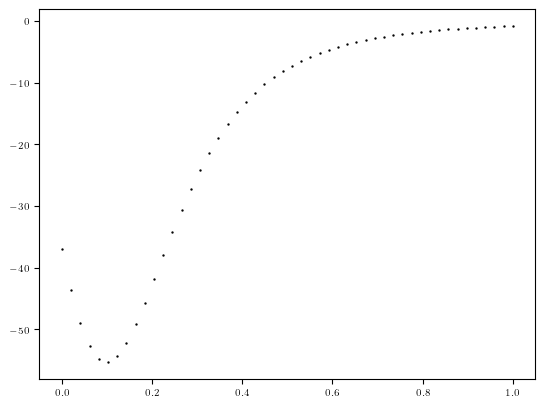

In [21]:
N = 50
h = 0.3
R = np.stack((np.linspace(0,1,N),np.ones(N)*h))
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
plt.figure()
for i in range(N):

    plt.scatter(R[0,i],dip_dip(R[:,i],d),color='0')
plt.show()


In [7]:
from qutip import enr_destroy, enr_fock, enr_identity, enr_state_dictionaries, tensor, Qobj
from scipy.special import factorial
from scipy.sparse import coo_matrix


def projector(excitations,chain_length,*operators):
        discard = int(factorial(excitations+chain_length-2)//(factorial(excitations-1)*factorial(chain_length-1)))
        new_qops = []
        for operator in operators:
            operator_full = operator.to("CSR").data_as("csr_matrix")
            operator_new = operator_full[discard:,discard:]
            # .tocoo()
            # data, coords = operator_full.data, operator_full.coords
            # coords = np.stack((coords[0]-discard,coords[1]-discard))
            # # print(coords)
            # # print(discard)
            # # coords -= discard
            # operator_new = coo_matrix((data,coords),shape=[operator_full.shape[0]-int(discard)]*2)#.tocsr()
            # print(type(operator_new))
            if len(operators)==1:
                return Qobj(operator_new)
            new_qops.append(Qobj(operator_new))
        return new_qops


def operators(chain_length,excit_phonons,excit_spin=1):
    dims_phonon = [excit_phonons+1]*chain_length
    dims_spin = [excit_spin+1]*chain_length
    destroy_phonon = enr_destroy(dims_phonon,excitations=excit_phonons)
    destroy_spin = enr_destroy(dims_spin,excitations=excit_spin)
    identity_phonon = projector(excit_phonons,chain_length,enr_identity(dims_phonon,excitations=excit_phonons))
    identity_spin = projector(excit_spin,chain_length,enr_identity(dims_spin,excitations=excit_spin))
    project_phonon = []
    project_spin =[]
    spin_flips = []
    phonon_flips = []
    eval_projector_spin = []
    eval_projector_phonon = []
    for i in range(len(destroy_phonon)):
        project_phonon.append(projector(excit_phonons,chain_length,destroy_phonon[i].dag()*destroy_phonon[i]))
        project_spin.append(projector(excit_spin,chain_length,destroy_spin[i].dag()*destroy_spin[i]))
        eval_projector_spin.append(tensor(project_spin[i],identity_phonon))
        eval_projector_phonon.append(tensor(identity_spin,project_phonon[i]))
        if i<len(destroy_phonon)-1:
            op_sp_flip = destroy_spin[i].dag()*destroy_spin[i+1]
            op_ph_flip = destroy_phonon[i].dag()*destroy_phonon[i+1]
            spin_flips.append(projector(excit_spin,chain_length,op_sp_flip))
            phonon_flips.append(projector(excit_phonons,chain_length,op_ph_flip))

    return phonon_flips, spin_flips, project_phonon, project_spin, identity_phonon ,identity_spin, eval_projector_spin[::-1]+eval_projector_phonon[::-1]


class system():
    def __init__(self,chain_length,excit_phonons,interaction_sp,interaction_spph,excit_spin=1,a=1,d=np.array([np.sqrt(1/3),np.sqrt(2/3)]),ph_scale=1/50):
        self.chain_length = chain_length
        self.excit_phonons = excit_phonons
        self.excit_spin = excit_spin
        self.interaction_sp = interaction_sp
        self.interaction_spph = interaction_spph
        self.a = a
        self.d = d
        self.ph_scale = ph_scale
        self.phonon_flips, self.spin_flips, self.project_phonon, self.project_spin, self.identity_phonon, self.identity_spin, self.projectors_eval = operators(chain_length,excit_phonons,excit_spin)
    param_trajectory = None
    
    # def projector(self,operator):
    #     discard = factorial(self.excit_spin+self.chain_length-2)//(factorial(self.excit_spin-1)*factorial(self.chain_length-1))
    #     operator_full = operator.to("CSR").data_as("csr_matrix").tocoo()
    #     data, coords = operator_full.data, operator_full.coords
    #     coords = np.stack((coords[0]-discard,coords[1]-discard))
    #     # print(coords)
    #     # print(discard)
    #     # coords -= discard
    #     operator_new = coo_matrix((data,coords),shape=[operator_full.shape[0]-int(discard)]*2)#.tocsr()
    #     # print(type(operator_new))
    #     return Qobj(operator_new)
        
    def Hamiltonian_spin_only(self,Delta,interaction1,interaction2):
        Ham_spin = 0
        # print(interaction1,interaction2,"spin")
        for i in range(self.chain_length//2):
            Ham_spin += Delta * tensor(self.project_spin[2*i],self.identity_phonon) - Delta * tensor(self.project_spin[2*i+1],self.identity_phonon)
            op = interaction1* tensor(self.spin_flips[2*i],self.identity_phonon)
            if  i<self.chain_length//2+self.chain_length%2-1:
                op2 = interaction2* tensor(self.spin_flips[2*i+1],self.identity_phonon)
                Ham_spin += op2 + op2.dag()
            Ham_spin += op+op.dag()
        # return 0
        return Ham_spin

    def Hamiltonian_spin_phonon(self,interaction1,interaction2):
        Ham_ps= 0
        # print(interaction1,interaction2,"phonon")
        for i in range(self.chain_length//2):
            op_ph = interaction1 * (self.phonon_flips[2*i]+ self.phonon_flips[2*i].dag()- self.project_phonon[2*i]- self.project_phonon[2*i+1])
            
            Ham_ps += tensor(self.spin_flips[2*i],op_ph)

            if i<self.chain_length//2+self.chain_length%2-1:

                op_ph2 = interaction2 * (self.phonon_flips[2*i+1]+ self.phonon_flips[2*i+1].dag()- self.project_phonon[2*i+1]- self.project_phonon[2*(i+1)]) 
                
                Ham_ps += tensor(self.spin_flips[2*i+1],op_ph2)

        return Ham_ps + Ham_ps.dag()
         


    def Hamiltonian_time(self,t):
        b, h, Delta = self.param_trajectory(t)
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        phonon_direction = 0
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        
        return self.Hamiltonian_spin_only(Delta,inter1,inter2) + self.ph_scale * self.Hamiltonian_spin_phonon(inter_ph1,inter_ph2)
    
    
    def Hamiltonian(self,b,h,Delta=0):
        latticeA = np.array([[0,0],[self.a,0]])
        latticeB = np.array([b,h])
        dist1 = latticeA[0]-latticeB
        dist2 = latticeA[1]-latticeB
        inter1 = dip_dip(dist1,self.d)
        inter2 = dip_dip(dist2,self.d)
        phonon_direction = 0
        inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,self.d)
        inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,self.d)
        
        return self.Hamiltonian_spin_only(Delta,inter1,inter2) + self.ph_scale * self.Hamiltonian_spin_phonon(inter_ph1,inter_ph2)






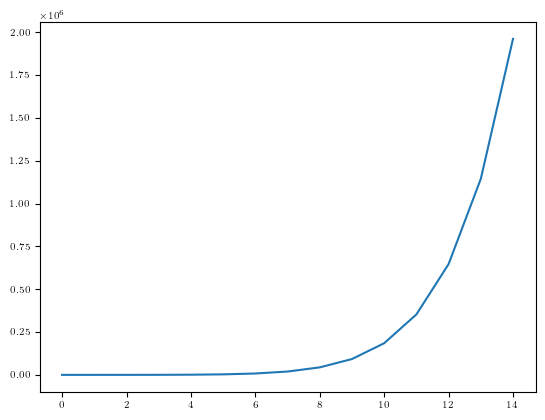

In [8]:
(2**6)
numb = 0
from scipy.special import binom
for i in range(7):
    numb += binom(6+i-1,i)

numb, binom(6,1)
n = 10
x = np.arange(3*n//2)
plt.plot(x,binom(n+x,x))
plt.show()

In [9]:
from qutip import tensor, basis, destroy, create, qeye, sesolve, sigmap, sigmam, fidelity, qzero, expect, ptrace
chain_length = 6
boson_number = 2


unity_spin = tensor([qeye(2)]*chain_length)
annihilation_phonon = []
phonon_projectors = []
for i in range(chain_length):
    op_list = []
    op_proj = []
    for j in range(chain_length):
        if i == j:
            op_list.append(destroy(boson_number))
            op_proj.append(create(boson_number)*destroy(boson_number))
        else:
            op_list.append(qeye(boson_number))
            op_proj.append(qeye(boson_number))
    annihilation_phonon.append(tensor(op_list))
    phonon_projectors.append(tensor([qeye(2)]*chain_length+op_proj))
unity_phonon = tensor([qeye(boson_number) for i in range(chain_length)])
sigmas_p = []
sigmas_m = []
onsite_projectors_spin = []
projectors_eval = []
for i in range(chain_length):
    op_list = []
    op_list_id = []
    for j in range(chain_length):
        if i == j:
            op_list.append(sigmap())
            op_list_id.append(sigmap()*sigmam())
        else:
            op_list.append(qeye(2))
            op_list_id.append(qeye(2))
    sigmas_p.append(tensor(op_list))
    sigmas_m.append(tensor(op_list).dag())
    onsite_projectors_spin.append(tensor(op_list_id))
    projectors_eval.append(tensor(tensor(op_list_id),unity_phonon))
projectors_eval = projectors_eval + phonon_projectors

def Hamiltonian_1Dph(Delta,b,h,a,phonon_direction,d,ph_scale):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeA[0]-latticeB
    dist2 = latticeA[1]-latticeB
    inter1 = dip_dip(dist1,d)
    inter2 = dip_dip(dist2,d)
    inter_ph1 = dip_derivative_full(dist1,phonon_direction,phonon_direction,d)
    inter_ph2 = dip_derivative_full(dist2,phonon_direction,phonon_direction,d)
    
    return Hamiltonian_spin_only(Delta,inter1,inter2) + ph_scale * Hamiltonian_spin_phonon(inter_ph1,inter_ph2)


def Hamiltonian_spin_only(Delta,interaction1,interaction2):
    Ham_spin = 0
    # print(interaction1,interaction2,"spin")
    for i in range(chain_length//2):
        Ham_spin += Delta * tensor(onsite_projectors_spin[2*i],unity_phonon) - Delta * tensor(onsite_projectors_spin[2*i+1],unity_phonon)
        op = interaction1* tensor(sigmas_p[i*2],unity_phonon)* tensor(sigmas_m[i*2+1],unity_phonon)
        if  i<chain_length//2+chain_length%2-1:
            op2 = interaction2* tensor(sigmas_p[i*2+1],unity_phonon) * tensor(sigmas_m[(i+1)*2],unity_phonon)
            Ham_spin += op2 + op2.dag()
        Ham_spin += op+op.dag()
    # return 0
    return Ham_spin

def Hamiltonian_spin_phonon(interaction1,interaction2):
    Ham_ps= 0
    # print(interaction1,interaction2,"phonon")
    for i in range(chain_length//2):
        op_ph = interaction1 * (annihilation_phonon[2*i].dag()*annihilation_phonon[2*i+1] + annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i].dag()*annihilation_phonon[2*i]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1])
        Ham_ps += tensor(sigmas_p[i*2]*sigmas_m[i*2+1],op_ph)
        # Ham_ps += tensor(sigmas_p[i*2+1]*sigmas_m[i*2],op_ph)
        # Ham_ps += tensor(unity_spin,op_ph)
        if i<chain_length//2+chain_length%2-1:
            op_ph2 = interaction2 * (annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*(i+1)] + annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*i+1].dag()*annihilation_phonon[2*i+1]-annihilation_phonon[2*(i+1)].dag()*annihilation_phonon[2*(i+1)])
            Ham_ps += tensor(sigmas_p[i*2+1]*sigmas_m[2*(i+1)],op_ph2)
            # Ham_ps += tensor(sigmas_p[2*(i+1)]*sigmas_m[i*2+1],op_ph2)
            # Ham_ps += tensor(unity_spin,op_ph2)
    # return 0
    return Ham_ps + Ham_ps.dag()
         

# H =Hamiltonian_1Dph(1,a/2,0,a,0,np.array([0,1]),1)


In [10]:
S = system(chain_length,1,dip_dip,dip_derivative_full)
b = 0.55
h = 0.4
H = S.Hamiltonian(b,h)
H.shape
enr_state_dictionaries([2]*3,excitations=1)
# projector(1,3,enr_destroy([2]*3,excitations=1)[0].dag()*enr_destroy([2]*3,excitations=1)[1])

(4,
 {(0, 0, 0): 0, (0, 0, 1): 1, (0, 1, 0): 2, (1, 0, 0): 3},
 {0: (0, 0, 0), 1: (0, 0, 1), 2: (0, 1, 0), 3: (1, 0, 0)})

In [11]:
operator = enr_destroy([2]*3,excitations=1)[0]
operator_full = operator.to("CSR").data_as("csr_matrix").tocoo()
from qutip import Qobj
operator, Qobj(operator_full)

(Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
 Qobj data =
 [[0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]],
 Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
 Qobj data =
 [[0. 0. 0. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]])

In [12]:
from random import random
a =2
def generate_random_initial():
    b = a*random()
    h = 0.6*random()
    r_vec1 = np.zeros((chain_length,chain_length))
    # r_vec2 = np.zeros(chain_length)
    for i in range(chain_length):
        for j in range(chain_length):
            r_vec1[i,j]= random()
        # r_vec2[i] = random()
    r_vec1 /= np.linalg.norm(r_vec1)
    # r_vec2 /= np.linalg.norm(r_vec2)
    return b, h, r_vec1#, r_vec2

b, h, eig0 = generate_random_initial()


1.0 0.06725611458010339 0.026841882776475166


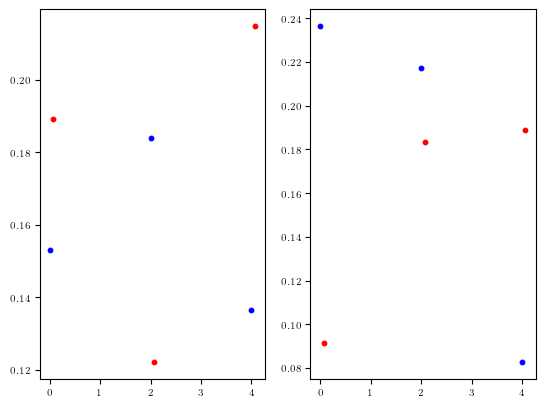

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/scipy/integrate/_ode.py:438: UserWarning: _zvode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


IntegratorException: Excess work done on this call. Try to increasing the nsteps parameter in the Options class

In [13]:
latticeA = np.zeros((2,chain_length//2+chain_length%2))
latticeB = np.zeros((2,chain_length//2))
atol = 1e-16
for n in range(latticeA.shape[1]):
    latticeA[:,n] = n*np.array([1,0])*a
for n in range(latticeB.shape[1]):
    latticeB[:,n] = n*np.array([1,0])*a + b*np.array([1,0])+h*np.array([0,1])
   

import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
ph_scale = 1/50

dt = 1
tsteps = 100
t = np.arange(tsteps)*dt
freq = 1/t[-1]


def Hamiltonian_spph_for_tevol(t):
    return Hamiltonian_1Dph(0,b,h,a,0,d,ph_scale)


down = tensor([basis(2,1) for i in range(chain_length)])

eig_generator_ph = 0
phonon0 = tensor([basis(boson_number,0) for i in range(chain_length)])
    
# for n in range(chain_length):
n=0
psi0q = 0
for i in range(chain_length):   
    for j in range(chain_length):
        state_sp = sigmas_p[i]* down
        state_ph = annihilation_phonon[j].dag()*phonon0
        psi0q += tensor(state_sp,state_ph)*eig0[i,j]#eigenvals0[n,1+chain_length*i+j]
    

psiq = psi0q.unit()
print(psi0q.norm(),b,h)   

# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#
fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[expect(projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[expect(projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj1 = sesolve(Hamiltonian_spph_for_tevol(0),psiq,t,e_ops=projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
print(Hamiltonian_spph_for_tevol(0).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj1.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj1.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()
    

1.0 0.8422019709888986 0.4873690203755675


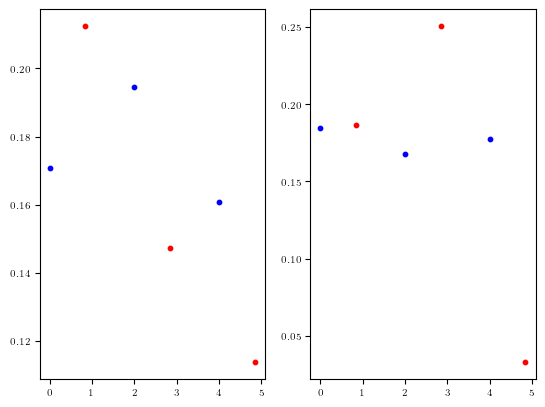

10.1%. Run time:   0.00s. Est. time left: 00:00:00:00
20.2%. Run time:   0.01s. Est. time left: 00:00:00:00
30.3%. Run time:   0.01s. Est. time left: 00:00:00:00
40.4%. Run time:   0.01s. Est. time left: 00:00:00:00
50.5%. Run time:   0.01s. Est. time left: 00:00:00:00
60.6%. Run time:   0.02s. Est. time left: 00:00:00:00
70.7%. Run time:   0.02s. Est. time left: 00:00:00:00
80.8%. Run time:   0.02s. Est. time left: 00:00:00:00
90.9%. Run time:   0.02s. Est. time left: 00:00:00:00
100.0%. Run time:   0.03s. Est. time left: 00:00:00:00
Total run time:   0.03s
size Hamiltonian:  (36, 36)


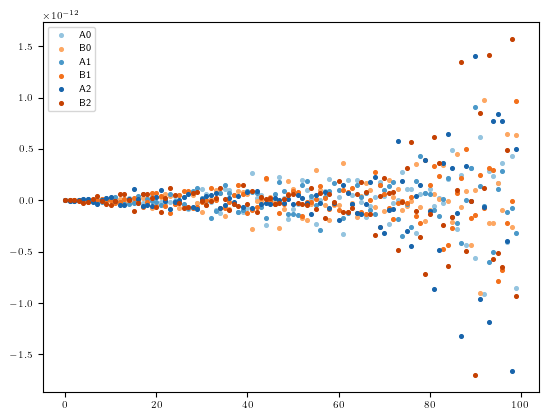

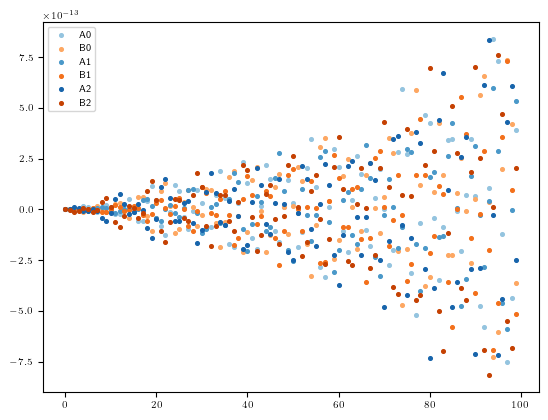

In [ ]:
state0 = 0
for i in range(chain_length):
    for j in range(chain_length):
        # state_sp = enr_fock([2]*chain_length,1,[1 if n==i else 0 for n in range(chain_length)])
        state_sp = Qobj(csr_matrix([1 if n==i else 0 for n in range(chain_length)]))
        # state_ph = enr_fock([2]*chain_length,1,[1 if n==j else 0 for n in range(chain_length)])
        state_ph = Qobj(csr_matrix([1 if n==j else 0 for n in range(chain_length)]))
        state0 += tensor(state_sp,state_ph) * eig0[i,j]

psiq = state0.unit().dag()
print(psiq.norm(),b,h)   
S= system(chain_length,1,dip_dip,dip_derivative_full,a=2)
projectors_eval2 = S.project_spin + S.project_phonon
# psiq = tensor(psi0q,eig_generator_ph*phonon0)
#
projectors_eval2[1], psiq

fig, ax = plt.subplots(1,2)
ax[0].scatter(latticeA[0,:],[expect(S.projectors_eval[2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[0].scatter(latticeB[0,:],[expect(S.projectors_eval[2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)

ax[1].scatter(latticeA[0,:],[expect(S.projectors_eval[chain_length+2*i],psiq) for i in range(chain_length//2+chain_length%2)],color='blue',s=10)
ax[1].scatter(latticeB[0,:],[expect(S.projectors_eval[chain_length+2*i+1],psiq) for i in range(chain_length//2)],color='red',s=10)
plt.show()
traj = sesolve(S.Hamiltonian(b,h),psiq,t,e_ops=S.projectors_eval,options={"progress_bar":True,"store_final_state":True,"atol":atol,"rtol":atol})
# t = t[:20],"store_states":True
print("size Hamiltonian: ",S.Hamiltonian(b,h).full().shape)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,traj.expect[chain_length+2*i]-traj1.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,traj.expect[chain_length+2*i+1]-traj1.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,traj.expect[2*i]-traj1.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,traj.expect[2*i+1]-traj1.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,traj.expect[chain_length-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,traj.expect[chain_length*2-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()


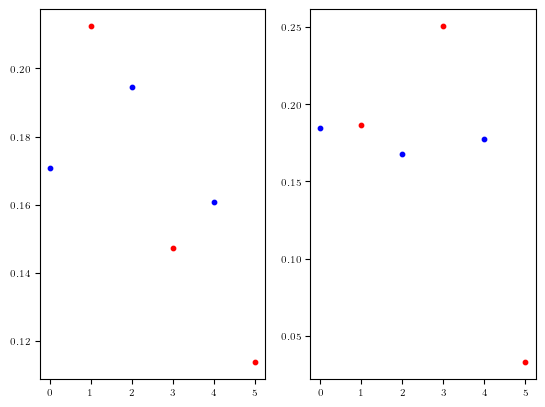

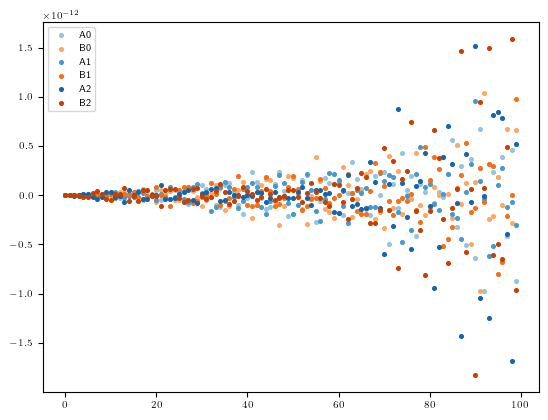

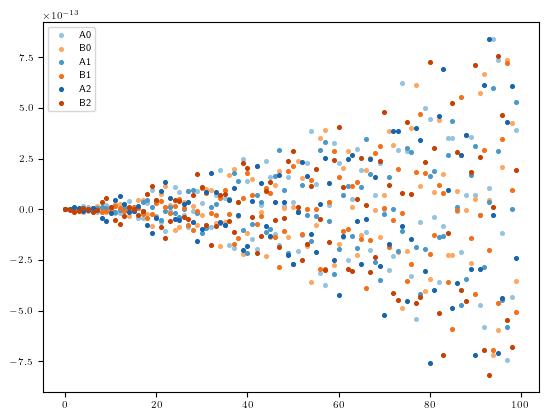

In [ ]:
def Ham_spph_full(b,h,a,d,ph_direction,chain_length,ph_strength,Delta=0):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeA[0]-latticeB
    dist2 = latticeA[1]-latticeB
    inter_ph1 = dip_derivative_full(dist1,ph_direction,ph_direction,d)*ph_strength
    inter_ph2 = dip_derivative_full(dist2,ph_direction,ph_direction,d)*ph_strength
    inter = dip_dip(dist1,d)
    inter2 = dip_dip(dist2,d)
    dmat = np.zeros((chain_length**2,chain_length**2))
    for i in range(chain_length//2):
        for j in range(chain_length):
            dmat[2*i*chain_length+j,(2*i+1)*chain_length+j] += inter
            if i<chain_length//2+chain_length%2-1:
                dmat[(2*i+1)*chain_length+j,2*(i+1)*chain_length+j] += inter2
        for j in range(2):
            dmat[2*i*chain_length+2*i,(2*i+1)*chain_length+2*i+j] += -(-1)**j*inter_ph1
            dmat[2*i*chain_length+2*i+1,(2*i+1)*chain_length+2*i+1-j] += -(-1)**j*inter_ph1
            if i<chain_length//2+chain_length%2-1:
                dmat[(2*i+1)*chain_length+2*i+1,2*(i+1)*chain_length+2*i+1+j] += -(-1)**j*inter_ph2
                dmat[(2*i+1)*chain_length+2*(i+1),2*(i+1)*chain_length+2*(i+1)-j] += -(-1)**j*inter_ph2
    dmat += dmat.T
    if Delta:
        ind = np.arange(chain_length,dtype=np.int16)
        for i in range(chain_length//2):
            
            dmat[ind,ind] = Delta
            ind += chain_length
            dmat[ind,ind] = -Delta
            ind += chain_length
        if chain_length%2:
            dmat[ind,ind] = Delta
    return dmat
# d = np.array([0,1])
# ph_scale = 1/scale_factor
def sintegrate(Ham,t,psi0,time_dependence=False):
    if time_dependence:
        def func(t,psi):
            dpsi = -1j*Ham(t) @ psi
            return dpsi
        def jac(t,psi):
            jacob = -1j*Ham(t)
            return jacob
    else:
        def func(t,psi):
            dpsi = -1j*Ham @ psi
            return dpsi
        def jac(t,psi):
            jacob = -1j*Ham
            return jacob
    r = ode(func,jac).set_integrator('zvode', method='adams',atol=atol,rtol=atol)
    r.set_initial_value(psi0, t[0])
    expect_spin = np.zeros((len(t),chain_length))
    expect_ph = np.zeros((len(t),chain_length))
  
    expect_spin[0,:] = [np.sum(np.abs(psi0[chain_length*j:chain_length*(j+1)])**2) for j in range(chain_length)]
    expect_ph[0,:] = [np.sum(np.abs(psi0[j::chain_length])**2) for j in range(chain_length)]
    
    
    for i,tval in enumerate(t[1:],1):
        r.integrate(tval)
        psi_t = r.y
        expect_spin[i,:] = [np.sum(np.abs(psi_t[chain_length*j:chain_length*(j+1)])**2) for j in range(chain_length)]
        expect_ph[i,:] = [np.sum(np.abs(psi_t[j::chain_length])**2) for j in range(chain_length)]
    
        
    return expect_spin, expect_ph

def stevol(t):
    return Ham_spph_full(b,h,a,d,0,chain_length,ph_scale)
# psi0 = eigenvals0[0,1:]
# psi0 = np.ones(chain_length**2,dtype=np.complex128)/chain_length**2
# psi0[0] =1
psi0 = np.zeros(chain_length**2,dtype=np.complex128)
for i in range(chain_length):
    for j in range(chain_length):
        psi0[i*chain_length+j] = eig0[i,j]


# psi0 = 1/np.sqrt(2)*(eigenvals0[0,1:]+eigenvals0[1,1:])
fig2, ax2 = plt.subplots(1,2)
for j in range(chain_length):
    
    ax2[0].scatter(j,np.sum(np.abs(psi0[chain_length*j:chain_length*(j+1)])**2),color=["blue",'red'][j%2],s=10)
    ax2[1].scatter(j,np.sum(np.abs(psi0[j::chain_length])**2),color=["blue",'red'][j%2],s=10)
plt.show()
traj2 = traj1
expect_spin, expect_ph = sintegrate(stevol(0), t, psi0, time_dependence=False)
# traj = scipy_evolve(stevol(0),  psi0,t)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
for i in range(chain_length//2):
    ax2.scatter(t,expect_ph[:,2*i]-traj2.expect[chain_length+2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax2.scatter(t,expect_ph[:,2*i+1]-traj2.expect[chain_length+2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
    ax.scatter(t,expect_spin[:,2*i]-traj2.expect[2*i],color=blue(0.4+0.6*i/(chain_length//2+chain_length%2)),s=7,label=f'A{i}')
    ax.scatter(t,expect_spin[:,2*i+1]-traj2.expect[2*i+1],color=orange(0.4+0.6*i/(chain_length//2)),s=7,label=f"B{i}")
# ax.scatter(t,expect_spin[:,-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
# ax2.scatter(t,expect_ph[:,-1],color=blue(0.4+0.6*(i+1)/(chain_length//2+chain_length%2)),s=7,label=f'A{i+1}')
ax.legend()
ax2.legend()
plt.show()